<a href="https://colab.research.google.com/github/Anagh19/Complex-Systems-Project/blob/refined_model/CS7065_DOI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setting up the import from Github for update ease, only need to run once per session

In [2]:
from pathlib import Path

repo_path = Path("/content/Complex-Systems-Project")

if not repo_path.exists():
    !git clone https://github.com/Anagh19/Complex-Systems-Project

%cd /content/Complex-Systems-Project

PROJECT_ROOT = Path.cwd()

Cloning into 'Complex-Systems-Project'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 55 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 2.38 MiB | 4.06 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/Complex-Systems-Project


In [84]:
try:
  import mesa
except:
  !pip install mesa --quiet
  import mesa

try:
  import mesa_geo as mg
except:
  !pip install -U --pre mesa-geo --quiet

try:
  import networkx as nx
except:
  !pip install networkx --quiet
  import networkx as nx

import numpy as np
import matplotlib.pyplot as plt
import math
import random
from shapely.geometry import Point
from mesa.discrete_space import CellCollection, Network, FixedAgent
state_regions = PROJECT_ROOT/"combined_counties.geojson"

In [85]:
try:
  import geopandas as gpd
except:
  !pip install geopandas --quiet
  import geopandas as gpd

Creating State Shapes

In [97]:
import shapely.geometry as geom
import geopandas as gpd

def create_states_from_geojson(filepath):
    gdf = gpd.read_file(filepath)
    # Assuming your GeoJSON has a 'NAME' column for state names/IDs and 'geometry' for polygons
    # You might need to adjust 'NAME' to the actual column name in your GeoJSON that represents the state ID.
    # Also, ensure the geometries are valid shapely Polygons or MultiPolygons.
    states = {}
    for index, row in gdf.iterrows():
        # Assuming a 'NAME' column identifies each state/county uniquely
        # If your GeoJSON has a different identifier, change 'NAME'
        state_id = row['STATEFP'] # or 'county_name' or whatever field identifies your regions
        states[state_id] = geom.MultiPolygon(row['geometry'])
    return states

# Using the previously defined PROJECT_ROOT and state_regions variable
STATE_POLYGONS = create_states_from_geojson(state_regions)
STATE_IDS = list(STATE_POLYGONS.keys())


In [77]:
"""import shapely.geometry as geom

def create_synthetic_states():
    # Three rectangular states
    states = {
        "A": geom.Polygon([(0,0),(10,0),(10,10),(0,10)]),
        "B": geom.Polygon([(10,0),(20,0),(20,10),(10,10)]),
        "C": geom.Polygon([(5,10),(15,10),(15,20),(5,20)])
    }
    return states

STATE_POLYGONS = create_synthetic_states()
STATE_IDS = list(STATE_POLYGONS.keys()) # A or B or C"""


HEALTH AGENT DEVELOPMENT!! \\
still need to develop spreading actions according to rules and maybe add color coding

In [78]:
class Health_Agent(FixedAgent):
  def __init__(
      self,
      model,
      agent_type, # LOCAL or STATE
      state_id,
      pos,
      num_of_connections,
      ):
    super().__init__(model)
    self.agent_type = agent_type
    self.state_id = state_id
    self.num_of_connections = num_of_connections
    self.pos = pos

    self.adopted = False # Inital condition for all agents since the agent is seeded in the model
    self.is_seed = False # Inital condition for all agents since the agent is seeded in the model

  def step(self):
    # replace this with spreading code eventually
    return print(f"Health Department {self.unique_id} from State {self.state_id}")


Health Model Development, need to add cacpability to add more agents , also have priority question for network generation

In [79]:
class Health_Model(mesa.Model):
  def __init__(
      self,
      num_agents,
      num_of_connections,
      dist_threshold,
      diffusion_mode = "government", # can also be localized
      num_states = 3,
      initial_seed = 1,
      seed_includes_state = False, # while the state can be the seed, its random
      rng=4,
      ):
    super().__init__(rng=rng)


    self.num_agents = num_agents
    self.seed_includes_state = seed_includes_state
    self.num_of_connections = num_of_connections
    self.dist_threshold = dist_threshold

    self.create_states()
    self.create_local()
    self.choose_seed()
    self.network = nx.Graph()

    for agent in self.state_agents + self.local_agents:
      self.network.add_node(agent.unique_id)
      self.network.nodes[agent.unique_id]['pos'] = agent.pos

    if diffusion_mode == "government":
      self.create_gov_network()
    else:
      self.create_local_network()

    self.datacollector = mesa.DataCollector(
            model_reporters={"Adopters": lambda m: sum(a.adopted for a in m.agents)}
    )


  def create_states(self):
    self.state_agents =[]
    for sid in STATE_IDS:
      poly = STATE_POLYGONS[sid]
      cx, cy = poly.centroid.coords[0]
      pos = (cx + random.uniform(-3,3), cy + random.uniform(-3,3))
      agents = Health_Agent.create_agents(model=self,n=1,agent_type="state", num_of_connections = 0,state_id = sid, pos=pos)

      self.state_agents.extend(agents)

  def create_local(self):
    self.local_agents =[]
    for i in range(self.num_agents - len(STATE_IDS)): # desired agents - state agents = # of local agents
      sid = random.choice(STATE_IDS)
      poly = STATE_POLYGONS[sid]
      cx, cy = poly.centroid.coords[0]
      pos = (cx + random.uniform(-5,5), cy + random.uniform(-5,5))
      agents = Health_Agent.create_agents(model=self,n=1,agent_type="local", num_of_connections=0, state_id = sid, pos=pos)

      self.local_agents.extend(agents)

  def create_gov_network(self):
       # State → State (federal) Prioritized as first
    for i, s1 in enumerate(self.state_agents): # No quota on states!!!! SHould be connected to every state and every local in their district
        for s2 in self.state_agents[i+1:]: # Avoid self-loops and duplicate edges
            self.network.add_edge(s1.unique_id, s2.unique_id)

       # State → Local Second Priority
    for s in self.state_agents:
      locals_in_state = [a for a in self.local_agents if a.state_id == s.state_id]
      for a in locals_in_state:
            self.network.add_edge(s.unique_id, a.unique_id)
            a.num_of_connections += 1

    # Local → Local (within same state) Last Priority
    for sid in STATE_IDS:
        locals_in_state = [a for a in self.local_agents if a.state_id == sid]
        for i, a1 in enumerate(locals_in_state):
            for a2 in locals_in_state[i+1:]: # Avoid self-loops and duplicate edges
              if a1.num_of_connections < self.num_of_connections and a2.num_of_connections < self.num_of_connections:
                self.network.add_edge(a1.unique_id, a2.unique_id)
                a1.num_of_connections += 1
                a2.num_of_connections += 1
              elif a.num_of_connections >= self.num_of_connections:
                print(f"Connection Quota Reached for {a2.unique_id} Agent with {a2.num_of_connections}")

  def create_local_network(self):
        # State → State (federal) 1st priority
    for i, s1 in enumerate(self.state_agents):
        for s2 in self.state_agents[i+1:]: # Avoid self-loops and duplicate edges
                self.network.add_edge(s1.unique_id, s2.unique_id)

    # State → Local second priority
    for s in self.state_agents:
      locals_in_state = [a for a in self.local_agents if a.state_id == s.state_id]
      for a in locals_in_state:
            self.network.add_edge(s.unique_id, a.unique_id)
            a.num_of_connections += 1

    # Local to locals last priority
    for i, a1 in enumerate(self.local_agents):
      for a2 in self.local_agents[i+1:]: # Avoid self-loops and duplicate edges
          d = math.dist(a1.pos, a2.pos)
          if d <= self.dist_threshold:  # using this as distance threshold
              if a1.num_of_connections < self.num_of_connections and a2.num_of_connections < self.num_of_connections:
                    self.network.add_edge(a1.unique_id, a2.unique_id)
                    a1.num_of_connections += 1
                    a2.num_of_connections += 1
              elif a2.num_of_connections >= self.num_of_connections:
                print(f"Connection Quota Reached for {a2.unique_id} Agent with {a2.num_of_connections}")

  def choose_seed(self):
    if self.seed_includes_state: # if the seed is a state agent
      seed = random.choice(self.state_agents)
    else:
      seed = random.choice(self.local_agents)
    seed.adopted = True
    seed.is_seed = True
    seed.exposures = 100 # random number of exposes since it doesn't matter
    self.seed_agent = seed

  def step(self):
    print(f"Health Dept {self.seed_agent.unique_id} from State {self.seed_agent.state_id} is the seed agent")
    self.agents.shuffle_do("step")
    self.datacollector.collect(self)

Currently this cell creates an instance of the model and runs it for 1 step which simply creates the agents and has them spit out their name and their state. Add functionality here to take user input and maybe create ipywidgets for fun



In [101]:
model = Health_Model(num_agents=50, num_of_connections= 3, diffusion_mode ="govement",dist_threshold=3, seed_includes_state=False)
model.run_for(1)

Connection Quota Reached for 14 Agent with 3
Connection Quota Reached for 24 Agent with 3
Health Dept 4 from State 18 is the seed agent
Health Department 39 from State 21
Health Department 23 from State 21
Health Department 38 from State 18
Health Department 22 from State 21
Health Department 17 from State 39
Health Department 50 from State 18
Health Department 45 from State 18
Health Department 49 from State 18
Health Department 41 from State 18
Health Department 42 from State 21
Health Department 8 from State 21
Health Department 14 from State 39
Health Department 33 from State 21
Health Department 30 from State 21
Health Department 35 from State 18
Health Department 13 from State 21
Health Department 11 from State 39
Health Department 3 from State 39
Health Department 32 from State 39
Health Department 40 from State 18
Health Department 44 from State 21
Health Department 43 from State 39
Health Department 28 from State 39
Health Department 25 from State 39
Health Department 29 from 

Plotting Package, need to update this so it can update with each step of the model if possible

This is a multi polygon
This is a multi polygon
This is a multi polygon


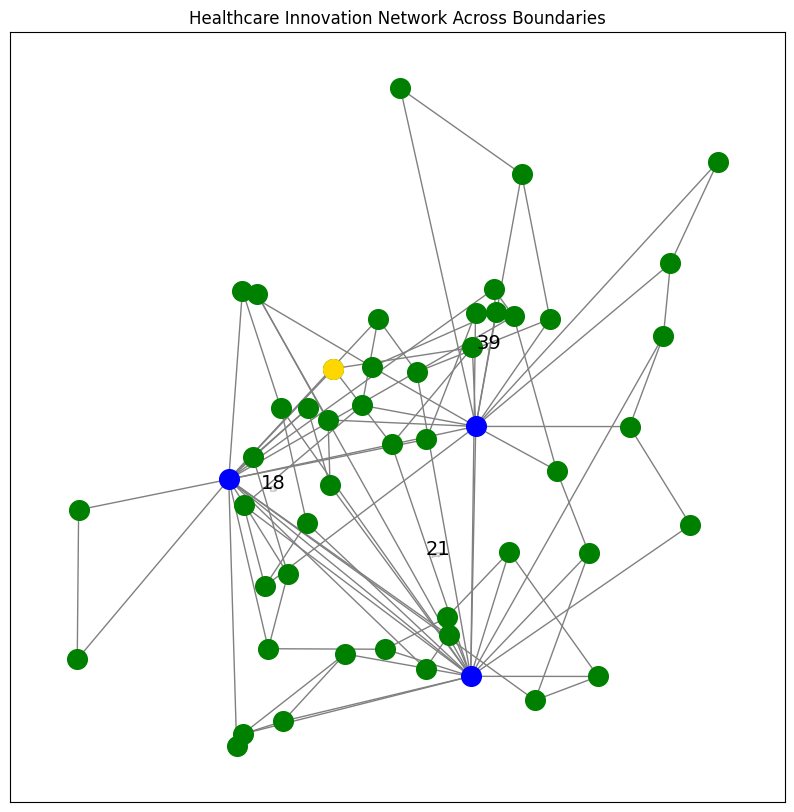

In [109]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import unary_union
fig, ax = plt.subplots(figsize=(10, 10))

# --- Plot state polygons ---
for sid, poly in STATE_POLYGONS.items():
      for p in poly.geoms:
            xs, ys = p.exterior.xy
            ax.fill(xs, ys, alpha=0.2, fc='lightgray', ec='black')
      ax.text(poly.centroid.x, poly.centroid.y, sid, fontsize=14, ha='center')
      print("This is a multi polygon")

# --- Plot network ---
positions = nx.get_node_attributes(model.network, 'pos')

# Draw edges
nx.draw_networkx_edges(model.network, positions, ax=ax, edge_color='gray')

# Draw local agents
local_nodes = [a.unique_id for a in model.local_agents]
nx.draw_networkx_nodes(
    model.network,
    positions,
    nodelist=local_nodes,
    node_color='green',
    node_size=200,
    ax=ax
)

# Draw state agents
state_nodes = [a.unique_id for a in model.state_agents]
nx.draw_networkx_nodes(
    model.network,
    positions,
    nodelist=state_nodes,
    node_color='blue',
    node_size=200,
    ax=ax
)

# Draw seed agent
nx.draw_networkx_nodes(
    model.network,
    positions,
    nodelist=[model.seed_agent.unique_id],
    node_color='gold',
    node_size=200,
    ax=ax
)

plt.title("Healthcare Innovation Network Across Boundaries")
plt.axis("equal")
plt.show()